<a href="https://colab.research.google.com/github/Malicef/Sistemas-Inteligentes-projeto1/blob/main/Usinas_de_ciclo_combinado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
import pandas as pd

In [ ]:
!pip install odfpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 717.0/717.0 kB 10.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for odfpy: filename=odfpy-1.4.1-py2.py3-none-any.whl size=160673 sha256=d2ed9e22572c746d3daed12bcdbdbbe20a5d377b558f965c5747212bab09cddc
  Stored in directory: /root/.cache/pip/wheels/36/5d/63/8243a7ee78fff0f944d638fd0e66d7278888f5e2285d7346b6
Successfully built odfpy


In [ ]:
dados = pd.read_excel('Folds5x2_pp.ods')
dados.head()

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


O dataset contem 9.568 amostras coletadas ao longo de 6 ano

In [ ]:
n_features = dados.shape[1]
print(f"\nNúmero de features: {n_features}")


Número de features: 5


**1**. Calcule a correlação entre as variáveis independentes (AT, V, AP, RH) e a variável dependente (PE). Quais
variáveis parecem ter maior influência na produção de energia?

In [ ]:
correlacoes = dados[["AT", "V", "AP", "RH", "PE"]].corr()["PE"]
correlacoes

,PE
AT,-0.948128
V,-0.869780
AP,0.518429
RH,0.389794
PE,1.000000


2. Calcule a correlação entre as variáveis independentes (AT, V, AP, RH) entre si. Existe alguma relação forte
entre elas? Se sim, isso pode indicar multicolinearidade.

In [ ]:

dados.corr()

,AT,V,AP,RH,PE
AT,1.000000,0.844107,-0.507549,-0.542535,-0.948128
V,0.844107,1.000000,-0.413502,-0.312187,-0.869780
AP,-0.507549,-0.413502,1.000000,0.099574,0.518429
RH,-0.542535,-0.312187,0.099574,1.000000,0.389794
PE,-0.948128,-0.869780,0.518429,0.389794,1.000000


3. Construa um modelo de regressão linear múltipla utilizando as variáveis independentes (AT, V, AP, RH)
para prever a variável dependente (PE). Divida os dados em treino (80%) e teste (20%).

In [ ]:
X = dados.drop(columns=["PE"])
y = dados["PE"]

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, random_state=42
)

modelo = LinearRegression()

# treinar o modelo
modelo.fit(X_treino, y_treino)

print(modelo)

LinearRegression()


Gráfico

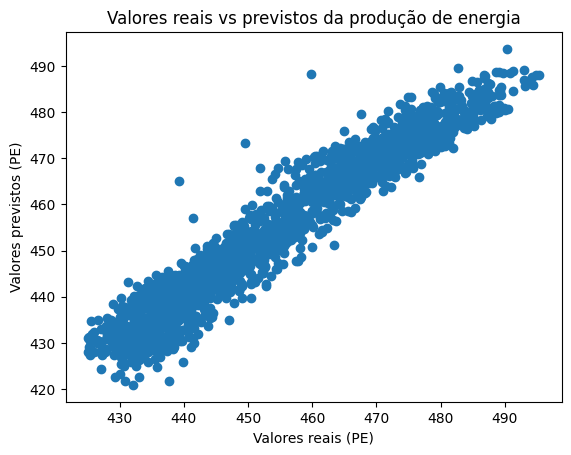

In [ ]:
import matplotlib.pyplot as plt

# previsões do modelo
y_pred = modelo.predict(X_teste)

# gráfico
plt.scatter(y_teste, y_pred)
plt.xlabel("Valores reais (PE)")
plt.ylabel("Valores previstos (PE)")
plt.title("Valores reais vs previstos da produção de energia")

plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

4. Avalie o desempenho do modelo utilizando metricas como R², RMSE e MAE. O modelo e adequado para
prever a producao de energia? Justifique sua resposta.

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np

# fazer previsões com o modelo treinado
y_pred = modelo.predict(X_teste)

# calcular métricas
r2 = r2_score(y_teste, y_pred)
rmse = np.sqrt(mean_squared_error(y_teste, y_pred))
mae = mean_absolute_error(y_teste, y_pred)

print("R²:", r2)
print("RMSE:", rmse)
print("MAE:", mae)

R²: 0.9301046431962188
RMSE: 4.502633229532186
MAE: 3.595913178273408
